In [1]:
print("hello")

hello


In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("credit_risk_dataset.csv")

In [4]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [5]:
df.shape

(32581, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [7]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


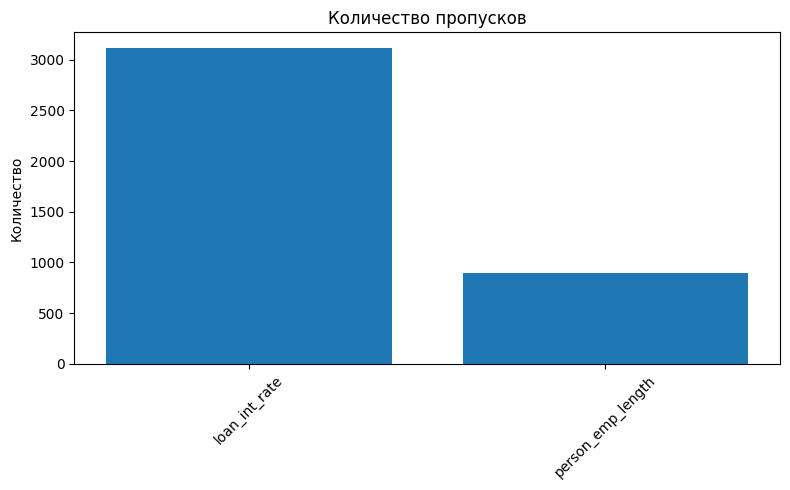

In [8]:
import matplotlib.pyplot as plt
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(missing.index, missing.values)
plt.title("Количество пропусков")
plt.ylabel("Количество")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

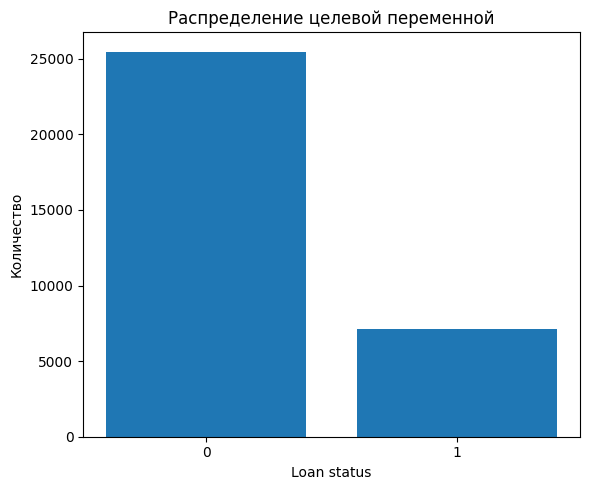

In [9]:
counts = df["loan_status"].value_counts().sort_index()

plt.figure(figsize=(6, 5))
plt.bar(["0", "1"], counts.values)
plt.title("Распределение целевой переменной")
plt.xlabel("Loan status")
plt.ylabel("Количество")
plt.tight_layout()
plt.show()

/tmp/ipykernel_5469/2748083915.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


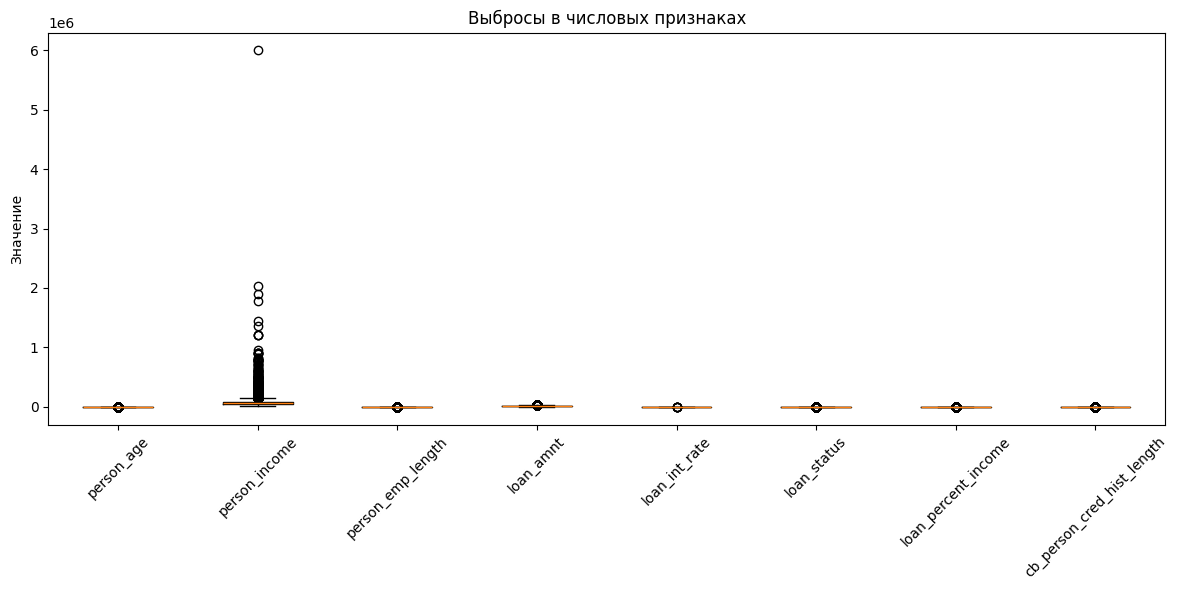

In [10]:
numeric_cols = df.select_dtypes(include="number").columns

plt.figure(figsize=(12, 6))
plt.boxplot(
    [df[col].dropna() for col in numeric_cols],
    labels=numeric_cols
)

plt.title("Выбросы в числовых признаках")
plt.xticks(rotation=45)
plt.ylabel("Значение")
plt.tight_layout()
plt.show()

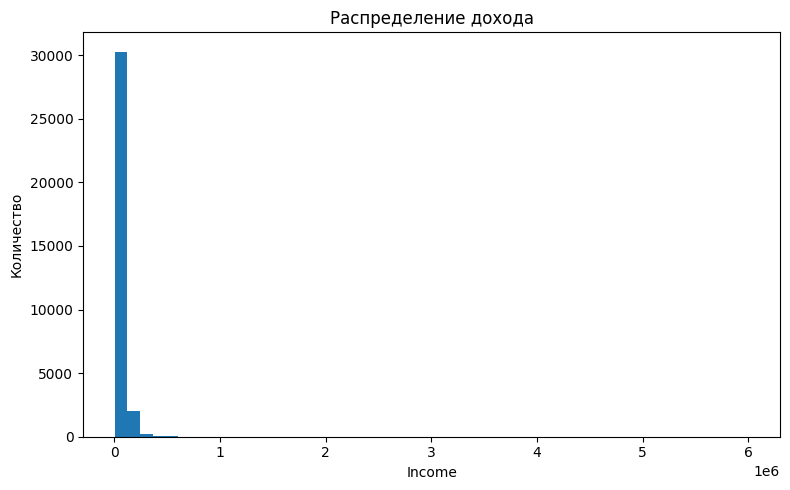

In [11]:
plt.figure(figsize=(8, 5))
plt.hist(df["person_income"].dropna(), bins=50)
plt.title("Распределение дохода")
plt.xlabel("Income")
plt.ylabel("Количество")
plt.tight_layout()
plt.show()

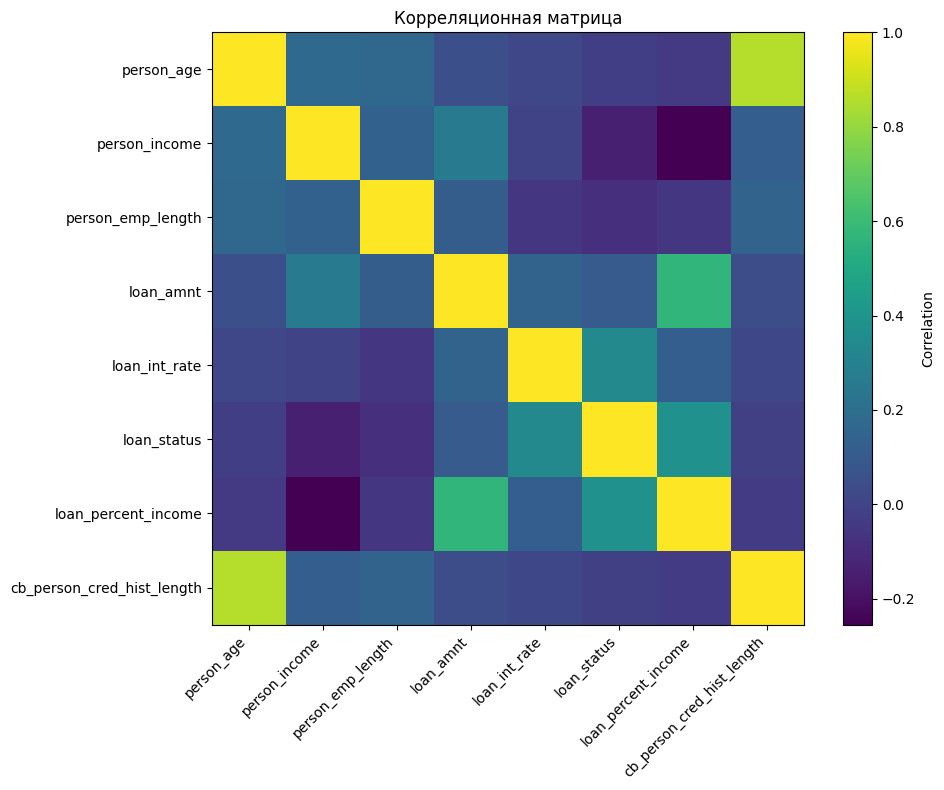

In [12]:
corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr)
plt.colorbar(label="Correlation")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Корреляционная матрица")
plt.tight_layout()
plt.show()

In [13]:
df['person_age'].sort_values(ascending = False)

,person_age
81,144
183,144
32297,144
575,123
747,123
...,...
1313,20
7748,20
7327,20
5648,20


In [14]:
df['person_emp_length'].sort_values(ascending = False)

,person_emp_length
210,123.0
0,123.0
32355,41.0
32515,38.0
32428,34.0
...,...
32285,NaN
32328,NaN
32360,NaN
32453,NaN


При первичном анализе были обнаружены нереалистичные экстремальные значения в признаках возраста и продолжительности занятости. Они были ограничены разумными верхними границами

In [15]:
df_clean = df.copy()

#Удаляем выбросы (например 144 летнего человека)
df_clean = df_clean[df_clean['person_age'] <= 80]

#Установим верхний предел продолжительности работы
df_clean = df_clean[df_clean['person_emp_length'] <= 60]

#Заполним пропуски медианой
df_clean['loan_int_rate'] = df_clean['loan_int_rate'].fillna(df_clean['loan_int_rate'].median())
df_clean['person_emp_length'] = df_clean['person_emp_length'].fillna(df_clean['person_emp_length'].median())

#закодируем бинарные категориальные признаки: Y/N → 1/0
df_clean['cb_person_default_on_file'] = (df_clean['cb_person_default_on_file'] == 'Y').astype(int)

#закодируем мульти-категориальные столбцы через One-hot-encoding
df_clean = pd.get_dummies(df_clean,
    columns=['person_home_ownership', 'loan_intent', 'loan_grade'],
    drop_first=True)

In [16]:
X = df_clean.drop(columns='loan_status')
y = df_clean['loan_status']

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [18]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [19]:
from  sklearn.linear_model import LogisticRegression
logreg_with_params = LogisticRegression(max_iter=1000,class_weight='balanced',random_state=42)

In [47]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_score, recall_score

logreg_with_params.fit(X_train_scaled, y_train)
lr_proba = logreg_with_params.predict_proba(X_test_scaled)[:, 1]


lr_pred = (lr_proba >= 0.5).astype(int)

log_reg_pr = precision_score(y_test, lr_pred)
log_reg_rc = recall_score(y_test, lr_pred)
lr_roc_auc = roc_auc_score(y_test, lr_proba)

print(f'Precision модели {log_reg_pr}')
print(f'Recall модели{log_reg_rc}')
print(f'F1 score модели {(2*log_reg_pr*log_reg_rc)/(log_reg_rc+log_reg_pr)}')
print(f'ROC-AUC модели {lr_roc_auc}')

Precision модели 0.5486005089058524
Recall модели0.7897435897435897
F1 score модели 0.6474474474474474
ROC-AUC модели 0.8769055393074705


In [21]:
from sklearn.ensemble import RandomForestClassifier

rand_forst = RandomForestClassifier(random_state = 42)


In [22]:
rand_forst.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [48]:
rd_res = rand_forst.predict_proba(X_test_scaled)[:,1]
rf_pred = (rd_res >= 0.5).astype(int)

rd_pr = precision_score(y_test, rf_pred)
rd_rc = recall_score(y_test, rf_pred)
rd_roc_auc = roc_auc_score(y_test, rd_res)

print(f'Precision модели {rd_pr}')
print(f'Recall модели{rd_rc}')
print(f'F1 score модели {(2*rd_pr*rd_rc)/(rd_pr+rd_rc)}')
print(f'ROC-AUC модели {rd_roc_auc}')

Precision модели 0.9578544061302682
Recall модели0.7326007326007326
F1 score модели 0.8302200083022
ROC-AUC модели 0.9360781912381188


In [24]:
from sklearn.metrics import average_precision_score

log_reg_pr_auc = average_precision_score(y_test, lr_proba)
random_forest_pr_auc = average_precision_score(y_test, rd_res)

print(f"PR-AUC для Логистической регрессии: {log_reg_pr_auc}")
print(f"PR-AUC для дремучего леса: {random_forest_pr_auc}")

PR-AUC для Логистической регрессии: 0.7295160574663654
PR-AUC для дремучего леса: 0.8880580063193974


Анализ логистической регрессии

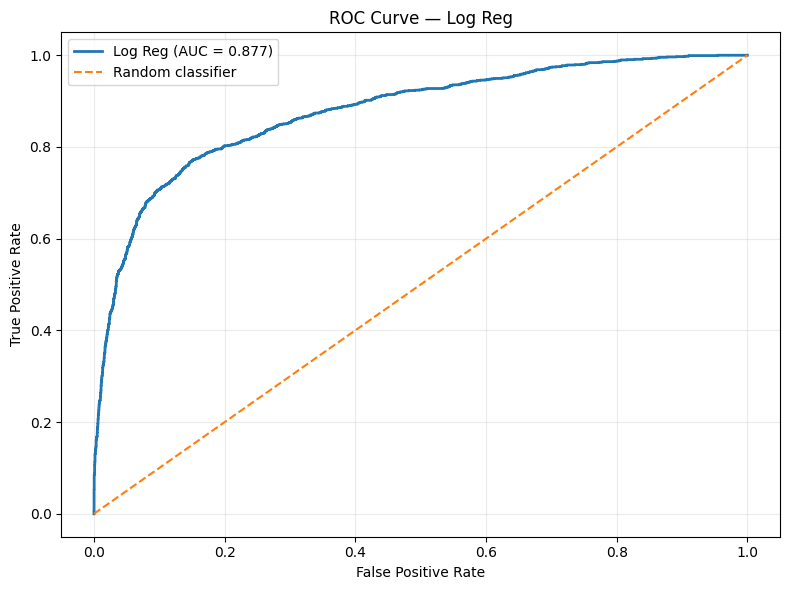

In [25]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, lr_proba)
rf_roc_auc = roc_auc_score(y_test, lr_proba)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr, tpr,
    linewidth=2,
    label=f"Log Reg (AUC = {lr_roc_auc:.3f})"
)

plt.plot(
    [0, 1], [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Log Reg")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

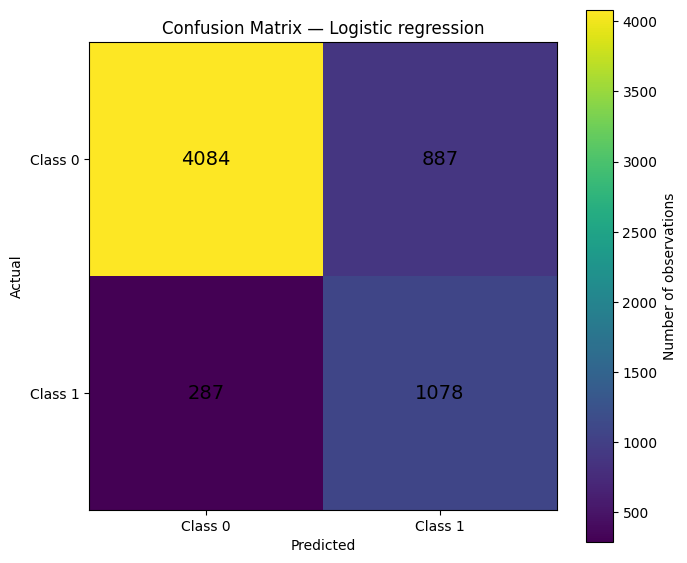

In [26]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
lg_pred = (lr_proba >= 0.5).astype(int)

cm = confusion_matrix(y_test, lg_pred)

plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.title("Confusion Matrix — Logistic regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["Class 0", "Class 1"])
plt.yticks([0, 1], ["Class 0", "Class 1"])

for i in range(2):
    for j in range(2):
        plt.text(
            j, i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=14
        )

plt.colorbar(label="Number of observations")
plt.tight_layout()
plt.show()

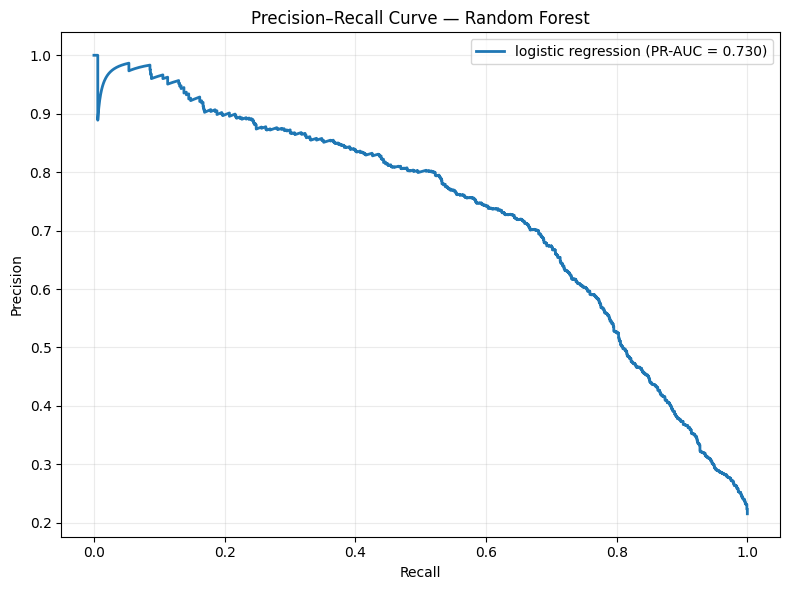

In [27]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, lr_proba)

pr_auc = average_precision_score(y_test, lr_proba)

plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision,
    linewidth=2,
    label=f"logistic regression (PR-AUC = {pr_auc:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve — Random Forest")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Анализ случайного леса


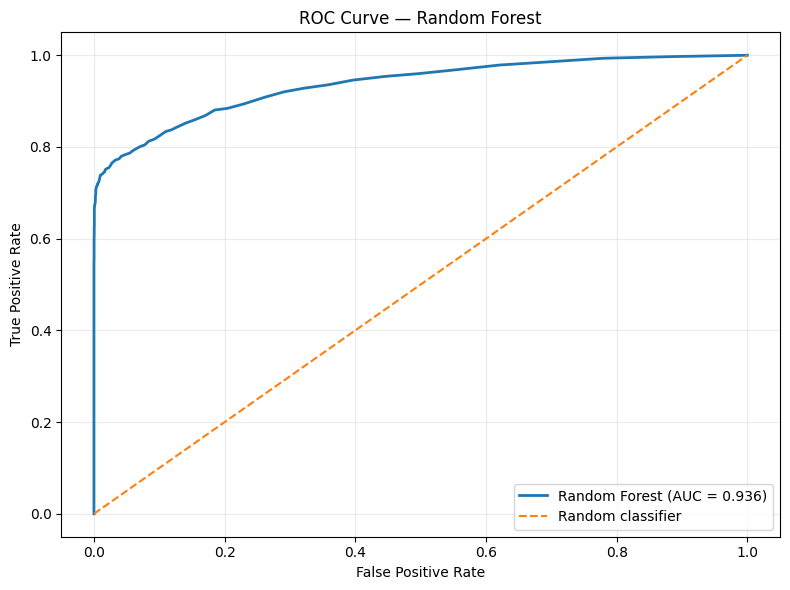

In [28]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, rd_res)
rf_roc_auc = roc_auc_score(y_test, rd_res)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr, tpr,
    linewidth=2,
    label=f"Random Forest (AUC = {rf_roc_auc:.3f})"
)

plt.plot(
    [0, 1], [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Random Forest")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

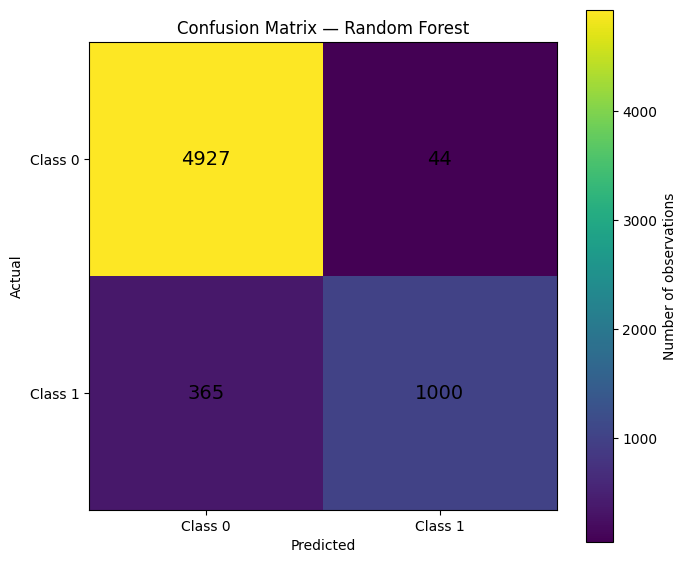

In [29]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
rf_pred = (rd_res >= 0.5).astype(int)

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.title("Confusion Matrix — Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["Class 0", "Class 1"])
plt.yticks([0, 1], ["Class 0", "Class 1"])

for i in range(2):
    for j in range(2):
        plt.text(
            j, i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=14
        )

plt.colorbar(label="Number of observations")
plt.tight_layout()
plt.show()

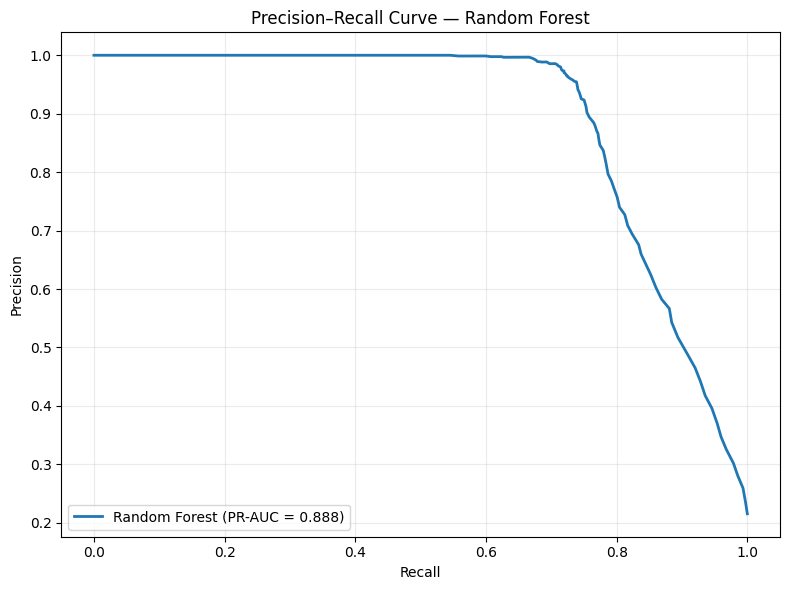

In [30]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, rd_res)

pr_auc = average_precision_score(y_test, rd_res)

plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision,
    linewidth=2,
    label=f"Random Forest (PR-AUC = {pr_auc:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve — Random Forest")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()